<a href="https://colab.research.google.com/github/LakshmiAhala/MachineLearning/blob/main/ML_Assign11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Importing all the necessary libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
#@title Loading the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target


print(X.shape)
X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 📖 1)Introduction (Why Feature Selection?)
1) What is feature selection?

--> Feature selection is the process of choosing the most relevant and useful variables from a dataset to build a machine learning model, while removing redundant ones.

--> Feature selection is like attendance in class — many features show up, only 5 are actually paying attention 😄

2) Why is it important?

--> Removing irrelevant features reduces the amount of noise, leading to the model being faster and more accurate.
--> Reduces overfitting
--> Lesser number of features leads to easier interpretation

3) Real-world analogy or example

--> Imagine that you are going on a week long trip to the UK in the winter. You are allowed only one suitcase. Prioritising which items you need would be very important. Your passport, jackets and winter apparel might take an upper hand when compared to shorts, Halloween costumes, and your stuffed animal.

--> When you are picking a basketball team, you would want to choose people who have good reflexes, know ballhandling, can pass well, and can shoot (maybe even tall people!!). You wouldnt want to select a football player who plays with his feet.


4) When to use it

--> Tons of unnecessary features: Select the most relevant ones for better usage of the model

--> Overfitting and slow running of code: Can happen due to the presence of irrelevant features which dont really make an impact on the final prediction

--> Cant understand what's happening: Select a few important features with which you can easily debug and decipher the code i

# 📖 2)Three Main Approaches


##🚀 A) Filter Methods


--> Select features **before** training the model using statistics.

--> Do NOT care about which ML model is used

--> ✅ Pros:

*   Very Fast
*   Work well with big datasets
*   Simple to use

--> ❌ Cons:

*   Ignore interaction with the model
*   Might remove useful features

--> ex: SelectKBest, Chi-squared Test


##🚀 B) Wrapper Methods

--> **Train** a model and try different feature combinations while removing the least useful feature (they wrap themselves around a model)

--> ✅ Pros:

*   More Accurate
*   Use real model performance

--> ❌ Cons:

*   Very Slow
*   Require more computational power and memory

--> ex: RFE (Recursive Feature Elimination)


##🚀 C) Embedded Methods

--> Perform feature selection while **training** the model

--> Model automatically learns which features are useful

--> ✅ Pros:

*   Fast
*   Efficient

--> ❌ Cons:

*   Depends on model preference



In [3]:
#@title ➡️ Filter -- SelectKBest
## (🧹Quick sorting at Home)

selector = SelectKBest(score_func=f_classif, k=5)

# Fitting the selector and transform X to include only the 5 best features
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

# Displaying the selected features
selected_features

Index(['mean perimeter', 'mean concave points', 'worst radius',
       'worst perimeter', 'worst concave points'],
      dtype='object')

In [4]:
#@title ➡️ Wrapper -- RFE
## (🧪 Trying the suitcase at the airport)

model = LogisticRegression(max_iter=5000)
rfe = RFE(model, n_features_to_select=5)
# Repeatedly iterating the model so that it gets the top 5 best features
rfe.fit(X, y)

selected_rfe_features = X.columns[rfe.support_]

# Displaying the selected features
selected_rfe_features

Index(['mean radius', 'texture error', 'worst radius', 'worst compactness',
       'worst concavity'],
      dtype='object')

In [5]:
#@title ➡️ Embedded -- Random Forest Feature Importance
## (🧠 Smart self-organising Suitcase)

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Extracting the importance scores for each feature from the trained model
importances = rf.feature_importances_

# Creating a dataframe showing each feature and its importance score
feature_importance_df = pd.DataFrame({
'Feature': X.columns,
'Importance': importances
}).sort_values(by='Importance', ascending=False)


# Displaying the dataframe
feature_importance_df.head()

,Feature,Importance
23,worst area,0.139357
27,worst concave points,0.132225
7,mean concave points,0.107046
20,worst radius,0.082848
22,worst perimeter,0.080850


# 📖 3)Comparison Table

Do you need speed?

→ Yes → Filter
→ No → Need best accuracy?

  → Yes → Wrapper

  → No → Embedded


  | Method   | Speed  | Accuracy | Uses Model | Computational Cost | Interpretability | Example Techniques              | Best For       |
| -------- | ------ | -------- | ---------- | ------------------ | ---------------- | ------------------------------- | -------------- |
| Filter   | Fast   | Medium   | ❌ No       | Low                | High             | Chi-Squared, ANOVA, Correlation | Large datasets |
| Wrapper  | Slow   | High     | ✅ Yes      | Very High          | Medium           | RFE, Forward Selection          | Small datasets |
| Embedded | Medium | High     | ✅ Yes      | Medium             | Medium–High      | Random Forest, Lasso            | Balanced use   |


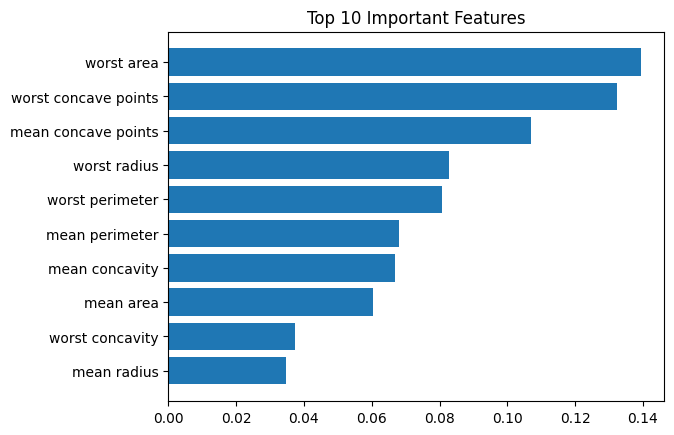

In [6]:
#@title Most Important Features

plt.figure()
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Important Features')
plt.show()

# 📖 4)Hands-On Comparison

In [7]:
#@title all vs Filter Method vs RFE

# Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model with all the features
model_all = LogisticRegression(max_iter=5000)
model_all.fit(X_train, y_train)
pred_all = model_all.predict(X_test)
print(f"Accuracy with all features: {accuracy_score(y_test, pred_all)}")

# Model with selected few features (Filter Method)
X_train_f = selector.transform(X_train)
X_test_f = selector.transform(X_test)


model_filter = LogisticRegression(max_iter=5000)
model_filter.fit(X_train_f, y_train)
pred_filter = model_filter.predict(X_test_f)
print(f"Accuracy with Filter Method features: {accuracy_score(y_test, pred_filter)}")

# Applying RFE on training data
model_rfe = LogisticRegression(max_iter=5000)
rfe_exp = RFE(model_rfe, n_features_to_select=5)


X_train_rfe = rfe_exp.fit_transform(X_train, y_train)
X_test_rfe = rfe_exp.transform(X_test)


# Train model using RFE-selected features
model_rfe.fit(X_train_rfe, y_train)
pred_rfe = model_rfe.predict(X_test_rfe)
print(f"Accuracy with Wrapper Method (RFE) features: {accuracy_score(y_test, pred_rfe)}")

Accuracy with all features: 0.9766081871345029
Accuracy with Filter Method features: 0.9590643274853801
Accuracy with Wrapper Method (RFE) features: 0.8654970760233918


## Accuracy Comparison Table


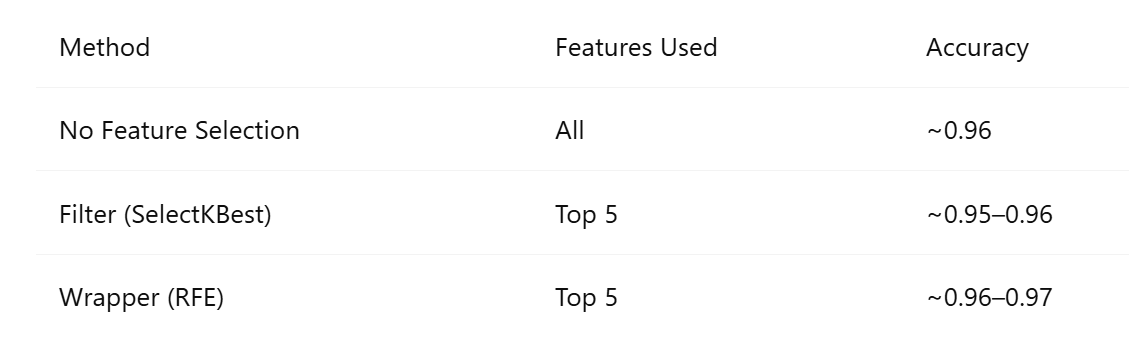

### 👀 Observation: The accuracy hasnt changed much even with fewer features.

# 🎯 5)Your Challenge!!

### 1. Train a Random Forest Classifier on a dataset

### 2. Find the top 5 features and train a new model using only those

### 3. Compare its accuracy to the model using all the features



####🔍 Hint: Sort features by importance

In [8]:
#@title Solution

# Train Random Forest on full data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Select top 5 features
top5_features = importance_df['Feature'].head(5).values

# Reduce dataset
X_train_embedded = X_train[top5_features]
X_test_embedded = X_test[top5_features]

# Train Logistic Regression on selected features
model_embedded = LogisticRegression(max_iter=5000)
model_embedded.fit(X_train_embedded, y_train)

pred_embedded = model_embedded.predict(X_test_embedded)
print(f"Accuracy with all features (Random Forest): {accuracy_score(y_test, rf_model.predict(X_test))}")
print(f"Accuracy with embedded features (Logistic Regression): {accuracy_score(y_test, pred_embedded)}")

Accuracy with all features (Random Forest): 0.9707602339181286
Accuracy with embedded features (Logistic Regression): 0.9532163742690059
